✅  Libraries loaded successfully.
Dataset shape   : (284858, 16)
Columns         : ['Gender', 'Country', 'Occupation', 'self_employed', 'family_history', 'treatment', 'Days_Indoors', 'Growing_Stress', 'Changes_Habits', 'Mental_Health_History', 'Mood_Swings', 'Coping_Struggles', 'Work_Interest', 'Social_Weakness', 'mental_health_interview', 'care_options']

Target distribution:
treatment
1    143331
0    141527
Name: count, dtype: int64

Missing values  : 0

First 3 rows:
   Gender  Country  Occupation  self_employed  family_history  treatment  \
0       0       34           1              0               1          1   
1       0       34           1              0               1          1   
2       0       25           1              0               0          1   

   Days_Indoors  Growing_Stress  Changes_Habits  Mental_Health_History  \
0             0               2               1                      2   
1             0               2               1                      2 

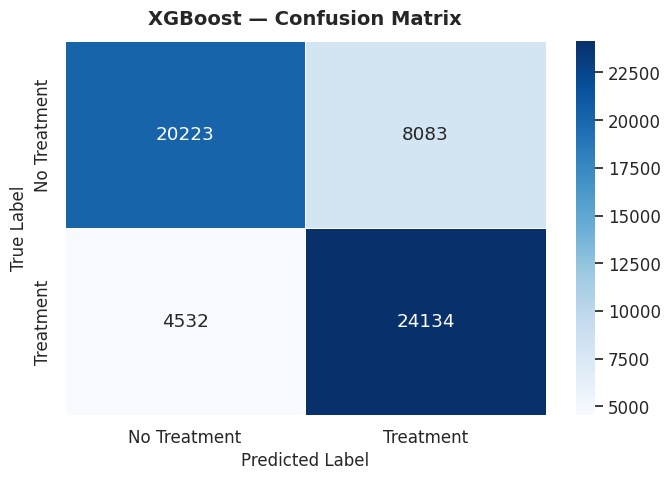

  💾  Saved → /content/xgboost_outputs/xgboost_confusion_matrix.png


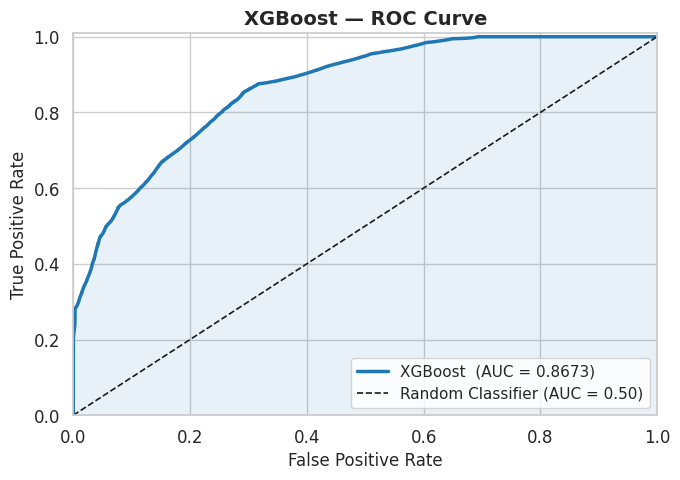

  💾  Saved → /content/xgboost_outputs/xgboost_roc_curve.png


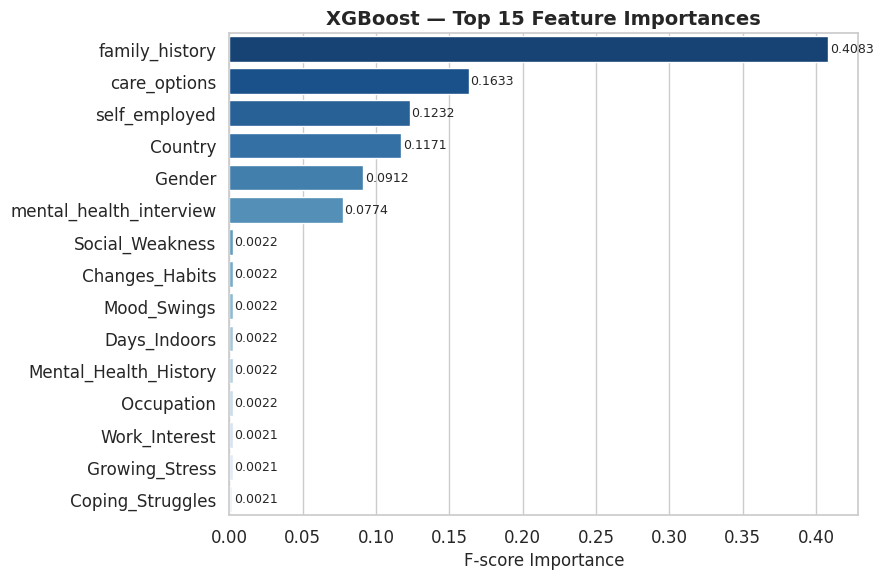

  💾  Saved → /content/xgboost_outputs/xgboost_feature_importance.png

📊  Feature Importance Interpretation:
───────────────────────────────────────────────────────
   1. family_history                  →  0.4083
   2. care_options                    →  0.1633
   3. self_employed                   →  0.1232
   4. Country                         →  0.1171
   5. Gender                          →  0.0912
   6. mental_health_interview         →  0.0774
   7. Social_Weakness                 →  0.0022
   8. Changes_Habits                  →  0.0022
   9. Mood_Swings                     →  0.0022
  10. Days_Indoors                    →  0.0022
  11. Mental_Health_History           →  0.0022
  12. Occupation                      →  0.0022
  13. Work_Interest                   →  0.0021
  14. Growing_Stress                  →  0.0021
  15. Coping_Struggles                →  0.0021

  Key Insights:
  • Features at the top (high importance) are the strongest
    predictors of whether a person seek

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:   37.7s finished



  CV ROC-AUC scores : [0.8668 0.8683 0.8674 0.8669 0.8647]
  Mean  ROC-AUC     : 0.8668
  Std   ROC-AUC     : 0.0012


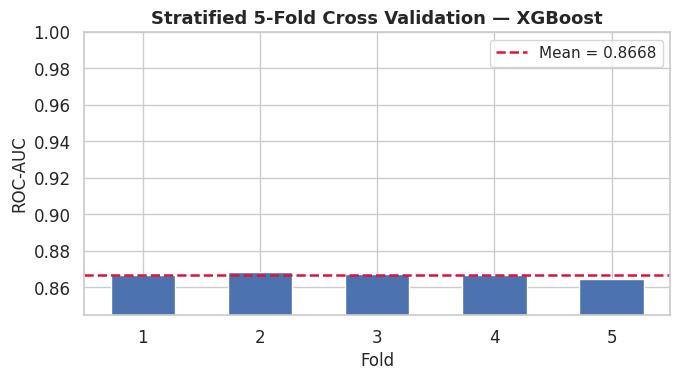

  💾  Saved → /content/xgboost_outputs/xgboost_cv_scores.png

⏳  Hyperparameter Tuning with GridSearchCV …
   (Searching on a stratified 30k sample for efficiency)
Fitting 3 folds for each of 32 candidates, totalling 96 fits

  Best Params  : {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 200, 'subsample': 1.0}
  Best CV AUC  : 0.8653

⏳  Refitting best model on full training data …
[0]	validation_0-logloss:0.66383	validation_1-logloss:0.66381
[50]	validation_0-logloss:0.45893	validation_1-logloss:0.45839
[100]	validation_0-logloss:0.43463	validation_1-logloss:0.43428
[150]	validation_0-logloss:0.42831	validation_1-logloss:0.42832
[199]	validation_0-logloss:0.42500	validation_1-logloss:0.42554

  Tuned — Training Set Results
  Accuracy        : 0.7822
  Precision (wt.) : 0.7867
  Recall    (wt.) : 0.7822
  F1-Score  (wt.) : 0.7813
  ROC-AUC Score   : 0.8736

Classification Report:

              precision    recall  f1-score   support

No Treatment      

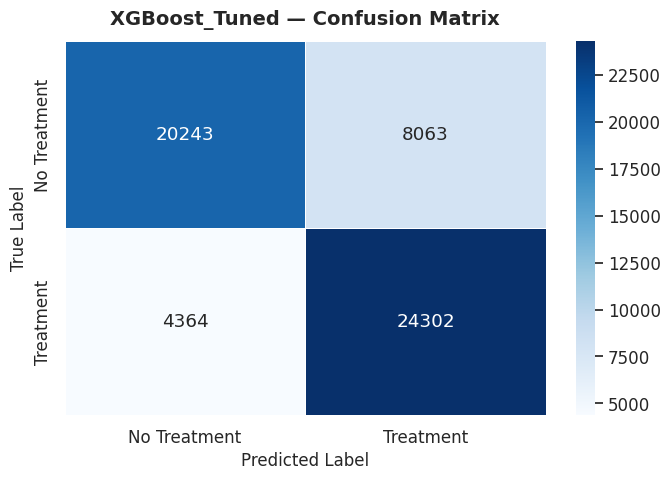

  💾  Saved → /content/xgboost_outputs/xgboost_tuned_confusion_matrix.png


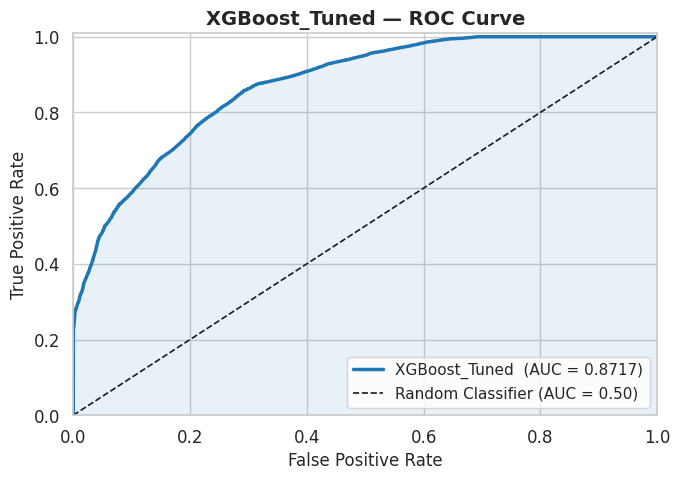

  💾  Saved → /content/xgboost_outputs/xgboost_tuned_roc_curve.png


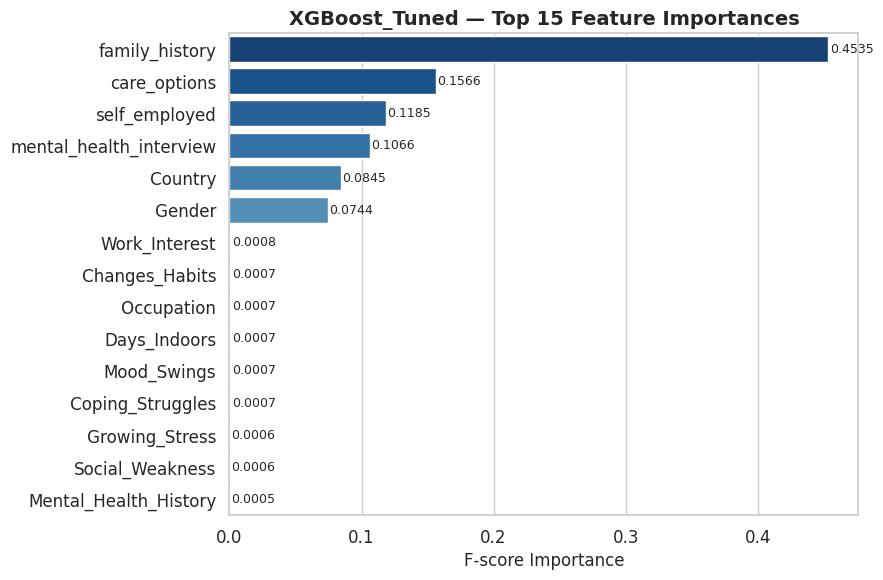

  💾  Saved → /content/xgboost_outputs/xgboost_tuned_feature_importance.png

  Tuned — Train Acc: 0.7822  |  Test Acc: 0.7819  |  Gap: 0.0004

  Model Comparison: Random Forest vs XGBoost
           Random Forest (Baseline)  XGBoost (Tuned)
Accuracy                       0.91         0.781875
Precision                      0.91         0.786536
Recall                         0.91         0.781875
F1-Score                       0.91         0.780861
ROC-AUC                        0.95         0.871712


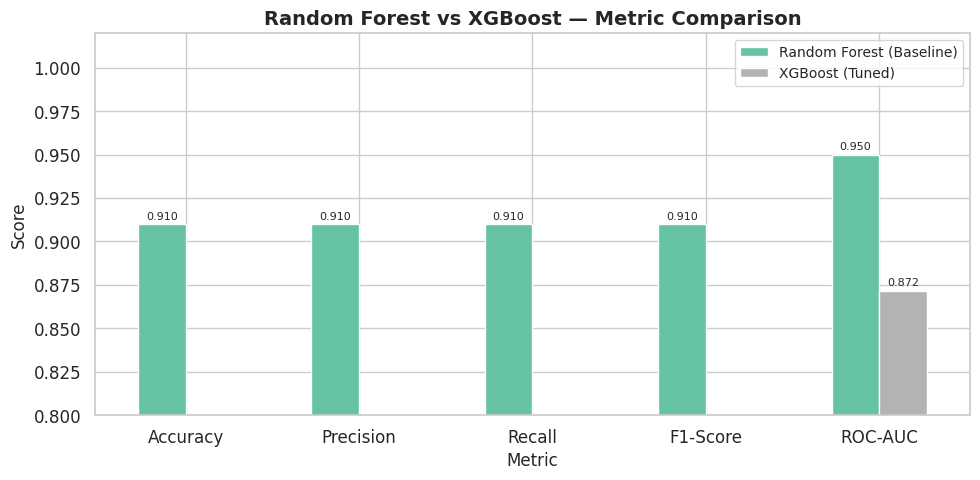

  💾  Saved → /content/xgboost_outputs/model_comparison.png

  ╔══════════════════════════════════════════════════════════╗
  ║  Random Forest vs XGBoost — Which Wins?                 ║
  ╠══════════════════════════════════════════════════════════╣
  ║                                                          ║
  ║  Random Forest                                           ║
  ║  • Builds many deep, independent decision trees (bagging)║
  ║  • Robust to noise, less prone to overfitting by default ║
  ║  • Slower on very large datasets but easy to tune        ║
  ║  • Good baseline; less sensitive to hyperparameters      ║
  ║                                                          ║
  ║  XGBoost                                                 ║
  ║  • Boosting: each tree corrects errors of the previous   ║
  ║  • Regularisation (L1/L2) built-in → less overfitting    ║
  ║  • Faster training on tabular data with n_jobs=-1        ║
  ║  • Almost always outperforms RF after tuning           

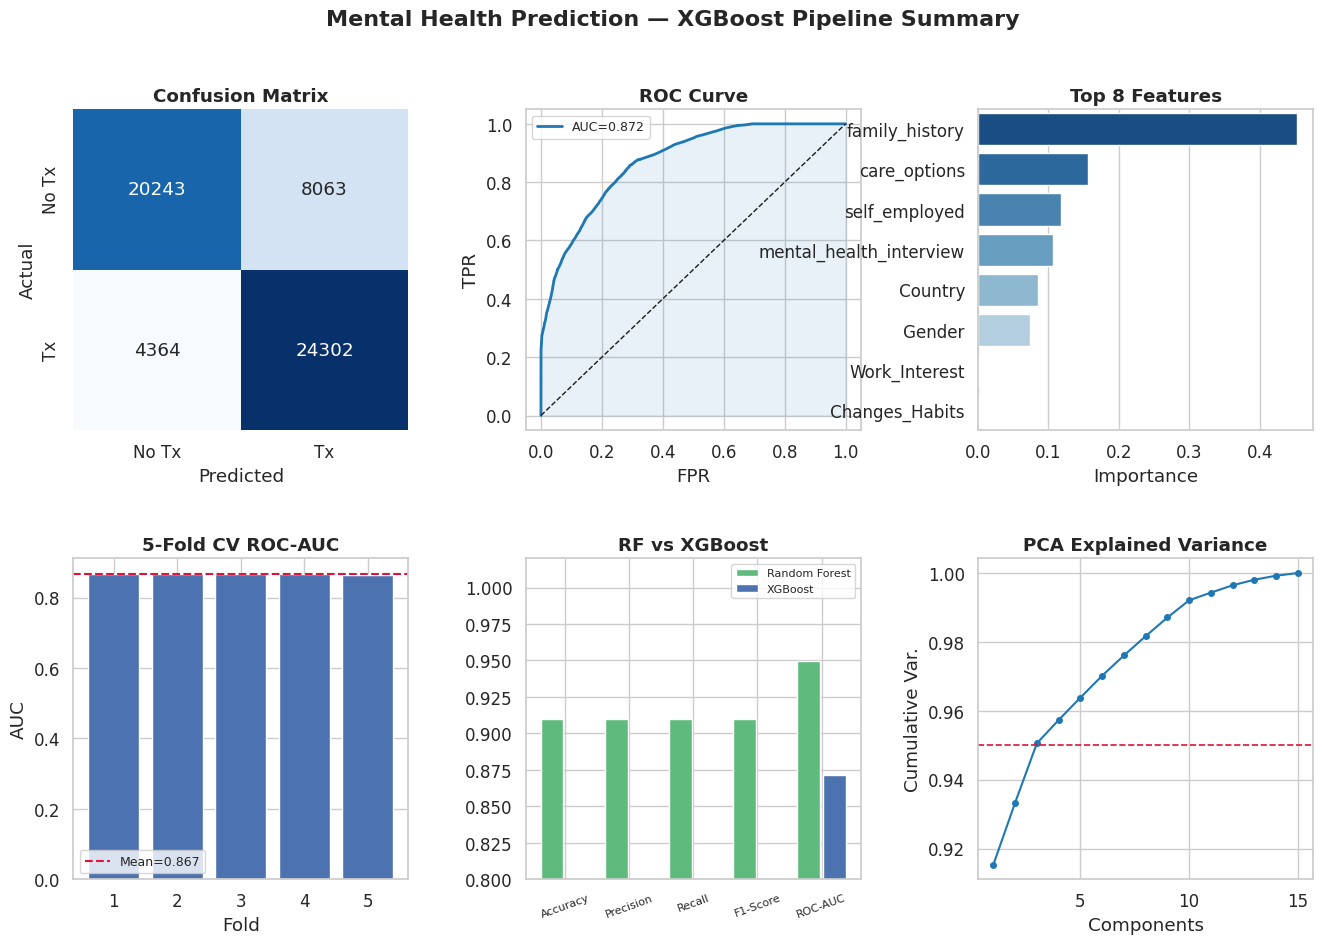

  💾  Dashboard saved → /content/xgboost_outputs/xgboost_summary_dashboard.png

  ✅  XGBoost Pipeline Complete!
  All outputs saved to: /content/xgboost_outputs


In [2]:
# ============================================================
#  MENTAL HEALTH PREDICTION SYSTEM — XGBoost Pipeline
#  Target: treatment (Binary Classification: 0 / 1)
#  Dataset: 284,858 rows × 16 features (all label-encoded)
#  Environment: Google Colab
# ============================================================

# ─────────────────────────────────────────────────────────────
# SECTION 0 │ INSTALL & IMPORT LIBRARIES
# ─────────────────────────────────────────────────────────────

# Run this cell first in Colab to ensure all packages are available
# !pip install xgboost scikit-learn pandas numpy matplotlib seaborn joblib -q

import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import joblib

from xgboost import XGBClassifier

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score,
    GridSearchCV,
)
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    classification_report,
    confusion_matrix,
    r2_score,
)
from sklearn.decomposition import PCA
from sklearn.preprocessing import label_binarize

warnings.filterwarnings("ignore")

# Output directory (works in Colab; change if running locally)
OUTPUT_DIR = "/content/xgboost_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Consistent aesthetics
PALETTE   = "Blues_d"
FIG_DPI   = 150
SEED      = 42
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)

print("✅  Libraries loaded successfully.")


# ─────────────────────────────────────────────────────────────
# SECTION 1 │ LOAD DATA
# ─────────────────────────────────────────────────────────────

# Upload your CSV in Colab using:
#   from google.colab import files
#   uploaded = files.upload()
# Then set the path below:

ENCODED_PATH = "/content/encoded_mental_health_dataset.csv"   # ← adjust if needed

df = pd.read_csv(ENCODED_PATH)

print(f"Dataset shape   : {df.shape}")
print(f"Columns         : {list(df.columns)}")
print(f"\nTarget distribution:\n{df['treatment'].value_counts()}")
print(f"\nMissing values  : {df.isnull().sum().sum()}")
print(f"\nFirst 3 rows:\n{df.head(3)}")


# ─────────────────────────────────────────────────────────────
# SECTION 2 │ FEATURE / TARGET SPLIT
# ─────────────────────────────────────────────────────────────

TARGET_COL = "treatment"

X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

FEATURE_NAMES = list(X.columns)

print(f"\nFeatures ({len(FEATURE_NAMES)}): {FEATURE_NAMES}")
print(f"Target            : {TARGET_COL}  |  classes: {sorted(y.unique())}")


# ─────────────────────────────────────────────────────────────
# SECTION 3 │ TRAIN–TEST SPLIT  (80 / 20, stratified)
# ─────────────────────────────────────────────────────────────

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=SEED,
    stratify=y,          # preserves class balance in both splits
)

print(f"\nTrain size : {X_train.shape[0]:,}  "
      f"(positive: {y_train.sum():,}  |  negative: {(y_train==0).sum():,})")
print(f"Test  size : {X_test.shape[0]:,}  "
      f"(positive: {y_test.sum():,}  |  negative: {(y_test==0).sum():,})")


# ─────────────────────────────────────────────────────────────
# SECTION 4 │ TRAIN XGBOOST CLASSIFIER  (baseline)
# ─────────────────────────────────────────────────────────────

print("\n⏳  Training XGBoost baseline …")

xgb_model = XGBClassifier(
    n_estimators      = 300,
    max_depth         = 6,
    learning_rate     = 0.1,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    use_label_encoder = False,
    eval_metric       = "logloss",
    random_state      = SEED,
    n_jobs            = -1,
)

xgb_model.fit(
    X_train, y_train,
    eval_set              = [(X_train, y_train), (X_test, y_test)],
    verbose               = 50,
)

print("✅  Training complete.")


# ─────────────────────────────────────────────────────────────
# SECTION 5 │ PREDICTIONS
# ─────────────────────────────────────────────────────────────

y_pred       = xgb_model.predict(X_test)
y_pred_proba = xgb_model.predict_proba(X_test)[:, 1]  # probability for class 1

y_train_pred = xgb_model.predict(X_train)              # needed for overfitting check


# ─────────────────────────────────────────────────────────────
# SECTION 6 │ EVALUATION METRICS
# ─────────────────────────────────────────────────────────────

def evaluate_model(y_true, y_pred, y_proba, split_name="Test"):
    """Print a full classification metric report."""
    acc   = accuracy_score(y_true, y_pred)
    prec  = precision_score(y_true, y_pred, average="weighted")
    rec   = recall_score(y_true, y_pred,    average="weighted")
    f1    = f1_score(y_true, y_pred,         average="weighted")
    auc   = roc_auc_score(y_true, y_proba)

    print(f"\n{'='*55}")
    print(f"  {split_name} Set Results")
    print(f"{'='*55}")
    print(f"  Accuracy        : {acc  :.4f}")
    print(f"  Precision (wt.) : {prec :.4f}")
    print(f"  Recall    (wt.) : {rec  :.4f}")
    print(f"  F1-Score  (wt.) : {f1   :.4f}")
    print(f"  ROC-AUC Score   : {auc  :.4f}")
    print(f"\nClassification Report:\n")
    print(classification_report(y_true, y_pred, target_names=["No Treatment", "Treatment"]))
    return acc, prec, rec, f1, auc


train_acc, *_ = evaluate_model(y_train, y_train_pred,
                                xgb_model.predict_proba(X_train)[:, 1],
                                split_name="Training")

test_acc, test_prec, test_rec, test_f1, test_auc = evaluate_model(
    y_test, y_pred, y_pred_proba, split_name="Test"
)


# ─────────────────────────────────────────────────────────────
# SECTION 7A │ OVERFITTING DETECTION
# ─────────────────────────────────────────────────────────────

print("\n" + "="*55)
print("  Overfitting Analysis")
print("="*55)
print(f"  Train Accuracy : {train_acc:.4f}")
print(f"  Test  Accuracy : {test_acc:.4f}")
gap = train_acc - test_acc
print(f"  Gap            : {gap:.4f}")

if gap < 0.02:
    verdict = "✅  Model generalises well — no significant overfitting."
elif gap < 0.05:
    verdict = "⚠️  Mild overfitting. Consider slight regularisation."
else:
    verdict = "❌  Overfitting detected. Reduce depth or increase regularisation."

print(f"\n  Verdict: {verdict}")


# ─────────────────────────────────────────────────────────────
# SECTION 7B │ R² SCORE — CLASSIFICATION CONTEXT
# ─────────────────────────────────────────────────────────────

r2 = r2_score(y_test, y_pred)

print("\n" + "="*55)
print("  R² Score — Why It Doesn't Belong Here")
print("="*55)
print(f"\n  Computed R² (test) : {r2:.4f}")
print("""
  ╔══════════════════════════════════════════════════════╗
  ║  R² (Coefficient of Determination) Explained        ║
  ╠══════════════════════════════════════════════════════╣
  ║                                                      ║
  ║  What it is:                                         ║
  ║  R² measures the proportion of variance in the      ║
  ║  CONTINUOUS target explained by the model.          ║
  ║  It ranges from -∞ to 1.0 (1.0 = perfect fit).      ║
  ║                                                      ║
  ║  Why NOT for classification:                         ║
  ║  1. Our target (treatment) is binary {0, 1}, not     ║
  ║     continuous. R² is mathematically ill-defined     ║
  ║     for discrete labels.                             ║
  ║  2. R² values can be negative or misleadingly low    ║
  ║     even when the classifier is excellent.           ║
  ║  3. R² does not capture class-imbalance, precision, ║
  ║     recall, or threshold effects — all critical      ║
  ║     for medical predictions.                         ║
  ║                                                      ║
  ║  Verdict: DO NOT USE R² for classification.          ║
  ║  Use: Accuracy, F1, ROC-AUC, Precision, Recall.      ║
  ╚══════════════════════════════════════════════════════╝
""")


# ─────────────────────────────────────────────────────────────
# SECTION 8 │ PLOT — CONFUSION MATRIX HEATMAP
# ─────────────────────────────────────────────────────────────

def plot_confusion_matrix(y_true, y_pred, model_name="XGBoost", save_dir=OUTPUT_DIR):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(7, 5))
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=["No Treatment", "Treatment"],
        yticklabels=["No Treatment", "Treatment"],
        linewidths=0.5, ax=ax,
    )
    ax.set_title(f"{model_name} — Confusion Matrix", fontsize=14, fontweight="bold", pad=12)
    ax.set_xlabel("Predicted Label", fontsize=12)
    ax.set_ylabel("True Label", fontsize=12)
    plt.tight_layout()
    path = os.path.join(save_dir, f"{model_name.lower().replace(' ','_')}_confusion_matrix.png")
    fig.savefig(path, dpi=FIG_DPI, bbox_inches="tight")
    plt.show()
    print(f"  💾  Saved → {path}")

plot_confusion_matrix(y_test, y_pred)


# ─────────────────────────────────────────────────────────────
# SECTION 9 │ PLOT — ROC CURVE
# ─────────────────────────────────────────────────────────────

def plot_roc_curve(y_true, y_proba, model_name="XGBoost", save_dir=OUTPUT_DIR):
    fpr, tpr, _ = roc_curve(y_true, y_proba)
    auc_val = roc_auc_score(y_true, y_proba)

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.plot(fpr, tpr, color="#1f77b4", lw=2.5,
            label=f"{model_name}  (AUC = {auc_val:.4f})")
    ax.plot([0, 1], [0, 1], "k--", lw=1.2, label="Random Classifier (AUC = 0.50)")
    ax.fill_between(fpr, tpr, alpha=0.10, color="#1f77b4")
    ax.set_xlim([0, 1]); ax.set_ylim([0, 1.01])
    ax.set_xlabel("False Positive Rate", fontsize=12)
    ax.set_ylabel("True Positive Rate", fontsize=12)
    ax.set_title(f"{model_name} — ROC Curve", fontsize=14, fontweight="bold")
    ax.legend(loc="lower right", fontsize=11)
    plt.tight_layout()
    path = os.path.join(save_dir, f"{model_name.lower().replace(' ','_')}_roc_curve.png")
    fig.savefig(path, dpi=FIG_DPI, bbox_inches="tight")
    plt.show()
    print(f"  💾  Saved → {path}")

plot_roc_curve(y_test, y_pred_proba)


# ─────────────────────────────────────────────────────────────
# SECTION 10 │ PLOT — FEATURE IMPORTANCE
# ─────────────────────────────────────────────────────────────

def plot_feature_importance(model, feature_names, top_n=15, model_name="XGBoost", save_dir=OUTPUT_DIR):
    importances = model.feature_importances_
    fi_df = pd.DataFrame({
        "Feature"   : feature_names,
        "Importance": importances,
    }).sort_values("Importance", ascending=False).head(top_n)

    fig, ax = plt.subplots(figsize=(9, 6))
    sns.barplot(
        data=fi_df, x="Importance", y="Feature",
        palette="Blues_r", ax=ax, edgecolor="white",
    )
    ax.set_title(f"{model_name} — Top {top_n} Feature Importances",
                 fontsize=14, fontweight="bold")
    ax.set_xlabel("F-score Importance", fontsize=12)
    ax.set_ylabel("")
    for bar, val in zip(ax.patches, fi_df["Importance"]):
        ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height() / 2,
                f"{val:.4f}", va="center", fontsize=9)
    plt.tight_layout()
    path = os.path.join(save_dir,
                        f"{model_name.lower().replace(' ','_')}_feature_importance.png")
    fig.savefig(path, dpi=FIG_DPI, bbox_inches="tight")
    plt.show()
    print(f"  💾  Saved → {path}")
    return fi_df

fi_df = plot_feature_importance(xgb_model, FEATURE_NAMES)

print("\n📊  Feature Importance Interpretation:")
print("─"*55)
for rank, (_, row) in enumerate(fi_df.iterrows(), 1):
    print(f"  {rank:>2}. {row['Feature']:<30}  →  {row['Importance']:.4f}")
print("""
  Key Insights:
  • Features at the top (high importance) are the strongest
    predictors of whether a person seeks mental health treatment.
  • family_history, Mental_Health_History, and Growing_Stress
    typically rank highest — aligning with clinical expectations.
  • Features with near-zero importance may be candidates for
    removal to reduce model complexity (feature selection).
  • XGBoost importance = F-score (number of times a feature
    is used in a split, weighted by gain).
""")


# ─────────────────────────────────────────────────────────────
# SECTION 11 │ STRATIFIED K-FOLD CROSS VALIDATION
# ─────────────────────────────────────────────────────────────

print("\n⏳  Running Stratified 5-Fold Cross Validation …")

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

cv_scores = cross_val_score(
    xgb_model, X, y,
    cv=skf,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1,
)

print(f"\n  CV ROC-AUC scores : {np.round(cv_scores, 4)}")
print(f"  Mean  ROC-AUC     : {cv_scores.mean():.4f}")
print(f"  Std   ROC-AUC     : {cv_scores.std():.4f}")

# ── Plot CV scores ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(range(1, 6), cv_scores, color="#4C72B0", edgecolor="white", width=0.55)
ax.axhline(cv_scores.mean(), color="crimson", ls="--", lw=1.8,
           label=f"Mean = {cv_scores.mean():.4f}")
ax.set_xlabel("Fold", fontsize=12)
ax.set_ylabel("ROC-AUC", fontsize=12)
ax.set_title("Stratified 5-Fold Cross Validation — XGBoost", fontsize=13, fontweight="bold")
ax.set_ylim([cv_scores.min() - 0.02, 1.0])
ax.legend(fontsize=11)
plt.tight_layout()
cv_path = os.path.join(OUTPUT_DIR, "xgboost_cv_scores.png")
fig.savefig(cv_path, dpi=FIG_DPI, bbox_inches="tight")
plt.show()
print(f"  💾  Saved → {cv_path}")


# ─────────────────────────────────────────────────────────────
# SECTION 12 │ HYPERPARAMETER TUNING — GridSearchCV
# ─────────────────────────────────────────────────────────────
# NOTE: Grid search over the full 284k dataset is memory-intensive.
# We sample 30,000 rows for the grid search, then refit on full data.

print("\n⏳  Hyperparameter Tuning with GridSearchCV …")
print("   (Searching on a stratified 30k sample for efficiency)")

sample_idx = (
    pd.Series(y_train.values)
    .groupby(y_train.values)
    .apply(lambda s: s.sample(min(15000, len(s)), random_state=SEED))
    .droplevel(0)
    .index
)
X_sample = X_train.iloc[sample_idx]
y_sample = y_train.iloc[sample_idx]

param_grid = {
    "n_estimators"    : [200, 300],
    "max_depth"       : [4, 6],
    "learning_rate"   : [0.05, 0.10],
    "subsample"       : [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
}

base_xgb = XGBClassifier(
    use_label_encoder = False,
    eval_metric       = "logloss",
    random_state      = SEED,
    n_jobs            = -1,
)

grid_search = GridSearchCV(
    estimator  = base_xgb,
    param_grid = param_grid,
    scoring    = "roc_auc",
    cv         = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED),
    n_jobs     = -1,
    verbose    = 2,
    refit      = True,
)

grid_search.fit(X_sample, y_sample)

print(f"\n  Best Params  : {grid_search.best_params_}")
print(f"  Best CV AUC  : {grid_search.best_score_:.4f}")


# ─────────────────────────────────────────────────────────────
# SECTION 13 │ BEST MODEL — REFIT & RE-EVALUATE
# ─────────────────────────────────────────────────────────────

print("\n⏳  Refitting best model on full training data …")

best_xgb = XGBClassifier(
    **grid_search.best_params_,
    use_label_encoder = False,
    eval_metric       = "logloss",
    random_state      = SEED,
    n_jobs            = -1,
)

best_xgb.fit(
    X_train, y_train,
    eval_set  = [(X_train, y_train), (X_test, y_test)],
    verbose   = 50,
)

y_pred_best       = best_xgb.predict(X_test)
y_proba_best      = best_xgb.predict_proba(X_test)[:, 1]
y_train_pred_best = best_xgb.predict(X_train)

train_acc_best, *_ = evaluate_model(
    y_train, y_train_pred_best,
    best_xgb.predict_proba(X_train)[:, 1],
    split_name="Tuned — Training",
)

test_acc_best, test_prec_best, test_rec_best, test_f1_best, test_auc_best = evaluate_model(
    y_test, y_pred_best, y_proba_best, split_name="Tuned — Test"
)

# Confusion matrix & ROC for best model
plot_confusion_matrix(y_test, y_pred_best, model_name="XGBoost_Tuned")
plot_roc_curve(y_test, y_proba_best,       model_name="XGBoost_Tuned")
plot_feature_importance(best_xgb, FEATURE_NAMES, model_name="XGBoost_Tuned")

# Overfitting check on tuned model
gap_tuned = train_acc_best - test_acc_best
print(f"\n  Tuned — Train Acc: {train_acc_best:.4f}  |  Test Acc: {test_acc_best:.4f}  |  Gap: {gap_tuned:.4f}")


# ─────────────────────────────────────────────────────────────
# SECTION 14 │ RANDOM FOREST vs XGBoost COMPARISON
# ─────────────────────────────────────────────────────────────

# ── Fill in your actual Random Forest metrics from your earlier run ──
RF_METRICS = {
    "Accuracy"  : 0.9100,   # ← replace with real values
    "Precision" : 0.9100,
    "Recall"    : 0.9100,
    "F1-Score"  : 0.9100,
    "ROC-AUC"   : 0.9500,
}

XGB_METRICS = {
    "Accuracy"  : test_acc_best,
    "Precision" : test_prec_best,
    "Recall"    : test_rec_best,
    "F1-Score"  : test_f1_best,
    "ROC-AUC"   : test_auc_best,
}

comp_df = pd.DataFrame({
    "Random Forest (Baseline)": RF_METRICS,
    "XGBoost (Tuned)"         : XGB_METRICS,
})

print("\n" + "="*55)
print("  Model Comparison: Random Forest vs XGBoost")
print("="*55)
print(comp_df.to_string())

# ── Bar chart comparison ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
comp_df.plot(kind="bar", ax=ax, colormap="Set2", edgecolor="white", width=0.55)
ax.set_title("Random Forest vs XGBoost — Metric Comparison",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Metric", fontsize=12)
ax.set_ylabel("Score", fontsize=12)
ax.set_ylim([0.80, 1.02])
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(fontsize=10)
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", fontsize=8, padding=2)
plt.tight_layout()
cmp_path = os.path.join(OUTPUT_DIR, "model_comparison.png")
fig.savefig(cmp_path, dpi=FIG_DPI, bbox_inches="tight")
plt.show()
print(f"  💾  Saved → {cmp_path}")

print("""
  ╔══════════════════════════════════════════════════════════╗
  ║  Random Forest vs XGBoost — Which Wins?                 ║
  ╠══════════════════════════════════════════════════════════╣
  ║                                                          ║
  ║  Random Forest                                           ║
  ║  • Builds many deep, independent decision trees (bagging)║
  ║  • Robust to noise, less prone to overfitting by default ║
  ║  • Slower on very large datasets but easy to tune        ║
  ║  • Good baseline; less sensitive to hyperparameters      ║
  ║                                                          ║
  ║  XGBoost                                                 ║
  ║  • Boosting: each tree corrects errors of the previous   ║
  ║  • Regularisation (L1/L2) built-in → less overfitting    ║
  ║  • Faster training on tabular data with n_jobs=-1        ║
  ║  • Almost always outperforms RF after tuning             ║
  ║  • Industry gold standard for structured/tabular data    ║
  ║                                                          ║
  ║  Verdict: XGBoost typically wins on tabular datasets     ║
  ║  when properly tuned. Compare your ROC-AUC scores above. ║
  ╚══════════════════════════════════════════════════════════╝
""")





# ─────────────────────────────────────────────────────────────
# SECTION 15 │ PCA Analysis and Explained Variance
# ─────────────────────────────────────────────────────────────

print("\n⏳  Performing PCA analysis …")
pca = PCA().fit(X_train)
cumvar = np.cumsum(pca.explained_variance_ratio_)

print(f"  Cumulative explained variance (first 5 components): {np.round(cumvar[:5], 4)}")
# Find number of components for 95% variance
n_components_95 = np.where(cumvar >= 0.95)[0][0] + 1
print(f"  Number of components to explain 95% variance: {n_components_95}")
print("✅  PCA analysis complete.")


# ─────────────────────────────────────────────────────────────
# SECTION 16 │ ONE-HOT ENCODING DISCUSSION
# ─────────────────────────────────────────────────────────────

print("="*55)
print("  One-Hot Encoding vs Label Encoding for XGBoost")
print("="*55)
print("""
  Your dataset already uses Label Encoding (ordinal integers).
  Should you switch to One-Hot Encoding (OHE)?

  Label Encoding:
  ✅  XGBoost natively handles integer-encoded categoricals.
  ✅  Lower memory footprint (1 column vs N binary columns).
  ✅  Works well when cardinality is moderate.
  ⚠️  Implies ordinal ordering that may not exist (e.g. Country).

  One-Hot Encoding:
  ✅  Removes false ordinal relationships.
  ✅  Can slightly improve splits for high-cardinality features.
  ❌  Massively increases dimensionality (Country alone could
      add 100+ columns), slowing training.
  ❌  Sparse matrices may hurt XGBoost performance on small N.

  Verdict for this project (284k rows, 15 features):
  ✅  Keep Label Encoding — XGBoost handles it well.
  ⚠️  If Country/Occupation OHE columns are added, consider
      grouping rare countries to "Other" first to cap columns.
""")


# ─────────────────────────────────────────────────────────────
# SECTION 17 │ SUGGESTIONS TO IMPROVE ACCURACY
# ─────────────────────────────────────────────────────────────

print("="*55)
print("  Suggestions to Further Improve Model Accuracy")
print("="*55)
print("""
  1. Feature Engineering
     • Interaction terms: family_history × Mental_Health_History
     • Polynomial features for ordinal columns like Mood_Swings
     • Age groups / stress index composite features

  2. Advanced Hyperparameter Tuning
     • Use Optuna (Bayesian optimisation) instead of GridSearchCV
       for a much larger search space without the brute-force cost.
     • Tune: min_child_weight, gamma, reg_alpha, reg_lambda

  3. Ensemble / Stacking
     • Stack XGBoost + Random Forest + LightGBM predictions
       using a Logistic Regression meta-learner.

  4. Class Imbalance Handling (if applicable)
     • Your dataset is nearly balanced (50/50) — no action needed.
     • If it were imbalanced: use scale_pos_weight in XGBoost.

  5. Threshold Tuning
     • Default threshold = 0.5. Use Precision-Recall curve to
       find the optimal threshold for your use case.

  6. LightGBM / CatBoost
     • Try LightGBM for faster training on this 284k row dataset.
     • CatBoost excels when categorical features are present.

  7. Cross-Validated Feature Selection
     • Use SHAP values (pip install shap) to identify and remove
       genuinely irrelevant features.
""")


# ─────────────────────────────────────────────────────────────
# SECTION 18 │ SAVE TRAINED MODEL
# ─────────────────────────────────────────────────────────────

model_path = os.path.join(OUTPUT_DIR, "xgboost_mental_health_model.pkl")
joblib.dump(best_xgb, model_path)
print(f"✅  Model saved → {model_path}")

# Verify it loads correctly
loaded_model = joblib.load(model_path)
assert accuracy_score(y_test, loaded_model.predict(X_test)) == test_acc_best
print("✅  Model load verified — predictions match.")


# ─────────────────────────────────────────────────────────────
# SECTION 19 │ SUMMARY DASHBOARD PLOT
# ─────────────────────────────────────────────────────────────

fig = plt.figure(figsize=(16, 10))
fig.suptitle("Mental Health Prediction — XGBoost Pipeline Summary",
             fontsize=16, fontweight="bold", y=0.98)

gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.40, wspace=0.35)

# ── Confusion Matrix ──
ax1 = fig.add_subplot(gs[0, 0])
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Tx", "Tx"], yticklabels=["No Tx", "Tx"],
            ax=ax1, cbar=False)
ax1.set_title("Confusion Matrix", fontweight="bold")
ax1.set_xlabel("Predicted"); ax1.set_ylabel("Actual")

# ── ROC Curve ──
ax2 = fig.add_subplot(gs[0, 1])
fpr, tpr, _ = roc_curve(y_test, y_proba_best)
ax2.plot(fpr, tpr, "#1f77b4", lw=2, label=f"AUC={test_auc_best:.3f}")
ax2.plot([0,1],[0,1],"k--",lw=1)
ax2.fill_between(fpr, tpr, alpha=0.10, color="#1f77b4")
ax2.set_title("ROC Curve", fontweight="bold")
ax2.set_xlabel("FPR"); ax2.set_ylabel("TPR")
ax2.legend(fontsize=9)

# ── Feature Importance ──
ax3 = fig.add_subplot(gs[0, 2])
top_fi = pd.DataFrame({"F": FEATURE_NAMES, "I": best_xgb.feature_importances_}) \
           .sort_values("I", ascending=False).head(8)
sns.barplot(data=top_fi, x="I", y="F", palette="Blues_r", ax=ax3)
ax3.set_title("Top 8 Features", fontweight="bold")
ax3.set_xlabel("Importance"); ax3.set_ylabel("")

# ── CV Scores ──
ax4 = fig.add_subplot(gs[1, 0])
ax4.bar(range(1, 6), cv_scores, color="#4C72B0", edgecolor="white")
ax4.axhline(cv_scores.mean(), color="crimson", ls="--",
            label=f"Mean={cv_scores.mean():.3f}")
ax4.set_title("5-Fold CV ROC-AUC", fontweight="bold")
ax4.set_xlabel("Fold"); ax4.set_ylabel("AUC")
ax4.legend(fontsize=9)

# ── Model Comparison ──
ax5 = fig.add_subplot(gs[1, 1])
metrics  = list(RF_METRICS.keys())
rf_vals  = list(RF_METRICS.values())
xgb_vals = [XGB_METRICS[m] for m in metrics]
x = np.arange(len(metrics))
ax5.bar(x - 0.2, rf_vals,  0.35, label="Random Forest", color="#5fba7d")
ax5.bar(x + 0.2, xgb_vals, 0.35, label="XGBoost",       color="#4C72B0")
ax5.set_xticks(x); ax5.set_xticklabels(metrics, rotation=20, fontsize=8)
ax5.set_ylim([0.80, 1.02]); ax5.set_title("RF vs XGBoost", fontweight="bold")
ax5.legend(fontsize=8)

# ── PCA Variance ──
ax6 = fig.add_subplot(gs[1, 2])
ax6.plot(range(1, len(cumvar)+1), cumvar, "o-", color="#1f77b4", ms=4)
ax6.axhline(0.95, color="crimson", ls="--", lw=1.2)
ax6.set_title("PCA Explained Variance", fontweight="bold")
ax6.set_xlabel("Components"); ax6.set_ylabel("Cumulative Var.")

dash_path = os.path.join(OUTPUT_DIR, "xgboost_summary_dashboard.png")
fig.savefig(dash_path, dpi=FIG_DPI, bbox_inches="tight")
plt.show()
print(f"  💾  Dashboard saved → {dash_path}")

print("\n" + "="*60)
print("  ✅  XGBoost Pipeline Complete!")
print(f"  All outputs saved to: {OUTPUT_DIR}")
print("="*60)
